# Environmental Benefits of 3D-Printed Biopolymer Materials

**Project:** RAW Project — 3D-Printed Biopolymer Panels  
**Database:** `lca_database_3DPrintedBiopol`  
**Ecoinvent version:** 3.12, cut-off system model  
**Date:** 2026  

## Purpose

This notebook computes the **unit environmental benefits** of each input material used in the 3D-printed biopolymer panel — i.e. the credits generated per 1 kg of material, independent of its share in any specific recipe. Three distinct benefit mechanisms are covered, each applicable to a different subset of materials depending on what's actually attributable to this product system:

- **Carbon sequestration credit** (Section 2) — for materials whose *growth* is part of this product system (annual crops, managed forestry): biogenic carbon temporarily stored in the panel, using the GWP_bio method (Guest et al., 2012).
- **Delayed-emissions credit** (Section 3) — for materials whose carbon uptake is *not* attributable to this system (wild-grown seagrass, industrial waste-stream cellulose): a smaller credit for delaying the release of carbon that was always going to be emitted, using dynamic characterization factors (Levasseur et al., 2010).
- **Avoided burden — nitrogen fixation** (Section 4) — a classic avoided-burden credit: peas fixing nitrogen offsets synthetic fertilizer production for a following crop.

Together these give each material a complete unit-benefit profile without double-crediting any single mechanism twice (see Section 3 for why seagrass/cellulose are handled separately from Section 2's crops/forestry).

Results are visualised as unit benefit bar charts (1 kg per material) and exported as a CSV for downstream use (e.g. the optimizer, the paper's results tables).

## Structure

| Section | Content |
|---|---|
| 0 | Setup, version pinning, and safety export |
| 1 | Load database and define materials of interest |
| 2 | Carbon sequestration credit — agricultural and forestry materials |
| 3 | Delayed-emissions credit — seagrass and cellulose |
| 4 | Avoided burden — nitrogen fixation (peas) |
| 5 | Visualizations and export |

---

## 0. Setup, version pinning, and safety export

In [7]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib.metadata
import os
from datetime import datetime, timezone

# ── Version pinning ───────────────────────────────────────────────────────────
# Print environment versions so the computational context is documented
# in the notebook output.
for pkg in ["bw2data", "bw2io", "bw2calc", "numpy", "pandas", "matplotlib"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")
print()

# ── Connect to project ────────────────────────────────────────────────────────
bd.projects.set_current("biopol_lca")
DB_NAME = "lca_database_3DPrintedBiopol"
db = bd.Database(DB_NAME)
ei = bd.Database("ecoinvent-3.12-cutoff")
print(f"  Foreground database: {DB_NAME} ({len(db)} activities)")
print(f"  ecoinvent: {len(ei)} datasets")

  bw2data: 4.4.2
  bw2io: 0.9.6
  bw2calc: 2.0.1
  numpy: 1.26.4
  pandas: 2.2.3
  matplotlib: 3.10.1

  Foreground database: lca_database_3DPrintedBiopol (14 activities)
  ecoinvent: 26533 datasets


In [8]:
# ── Safety export ─────────────────────────────────────────────────────────────
# This notebook only reads from the foreground database (it does not modify
# recipes or activities), so this export is a timestamped snapshot for
# archival/reproducibility rather than a pre-deletion backup.
TIMESTAMP  = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
EXPORT_DIR = "../results/lca_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

export_path = bi.export.write_lci_excel(DB_NAME, dirpath=EXPORT_DIR)
base, ext = os.path.splitext(export_path)
stamped_path = f"{base}_{TIMESTAMP}{ext}"
os.rename(export_path, stamped_path)
print(f"Database snapshot exported to: {stamped_path}")

Database snapshot exported to: ../results/lca_export/lci-lca_database_3DPrintedBiopol_20260709_080609.xlsx


## 1. Load database and define materials of interest

This notebook evaluates unit benefits for the same seven input materials used throughout the RAW Project LCA: the pea protein binder and the six filler options. Each material is retrieved as its Brightway production activity so that Sections 2–3 can run per-material calculations (sequestration, avoided burden) and per-material LCIA scores at a functional unit of **1 kg of material, as produced**.

Note this is a different functional unit than the panel-level notebooks (`01_LifeCycleInventory_master.ipynb`, `02_LifeCycleImpactAssessment_burdens_EFv3_1.ipynb`), which evaluate 1 kg of finished, baked panel. Here we deliberately step back to 1 kg of *input material* to produce recipe-independent unit benefit values.

In [9]:
# ── Materials of interest ─────────────────────────────────────────────────────
# Same seven foreground materials used throughout the RAW Project LCA.
# Keys are display labels; values are exact Brightway activity names.

MATERIAL_ACTIVITIES = {
    "Pea protein binder":   "pea protein binder production",
    "Seagrass filler":      "seagrass filler production",
    "Bark flour filler":    "bark flour filler production",
    "Cellulose filler":     "cellulose filler production",
    "Cotton filler":        "cotton filler production",
    "Hemp dust filler":     "hemp dust filler production",
    "Wood flour filler":    "wood flour filler production",
}

# ── Retrieve activity objects ─────────────────────────────────────────────────
material_acts = {}
for label, name in MATERIAL_ACTIVITIES.items():
    results = [a for a in db if a["name"] == name]
    if not results:
        print(f"WARNING: '{name}' not found")
    else:
        material_acts[label] = results[0]

print(f"Loaded {len(material_acts)} / {len(MATERIAL_ACTIVITIES)} material activities:")
for label, act in material_acts.items():
    print(f"  {label:<20s} → {act['name']}  (id={act.id})")

Loaded 7 / 7 material activities:
  Pea protein binder   → pea protein binder production  (id=332789646792474624)
  Seagrass filler      → seagrass filler production  (id=332789530987741184)
  Bark flour filler    → bark flour filler production  (id=332789548930973696)
  Cellulose filler     → cellulose filler production  (id=332789549128105984)
  Cotton filler        → cotton filler production  (id=332789562247888896)
  Hemp dust filler     → hemp dust filler production  (id=332789562398883840)
  Wood flour filler    → wood flour filler production  (id=332789572377133056)


In [10]:
# ── Focal impact categories ───────────────────────────────────────────────────
# Full method tuples confirmed against bd.methods for EF v3.1.
# Used in Section 3 (avoided burden) and Section 4 (visualisation/export).

METHOD_GWP  = [m for m in bd.methods if m[0] == 'EF v3.1' and 'climate change' == m[1] and 'global warming potential (GWP100)' in m[2]][0]
METHOD_LAND = [m for m in bd.methods if m[0] == 'EF v3.1' and 'land use' == m[1]][0]
METHOD_EUTR = [m for m in bd.methods if m[0] == 'EF v3.1' and 'eutrophication: terrestrial' == m[1]][0]

FOCAL_METHODS = {
    'GWP100':                  METHOD_GWP,
    'Land use':                METHOD_LAND,
    'Eutrophication (terr.)':  METHOD_EUTR,
}

print("Focal impact categories:")
for label, method in FOCAL_METHODS.items():
    print(f"  {label:<25s} {method}")

Focal impact categories:
  GWP100                    ('EF v3.1', 'climate change', 'global warming potential (GWP100)')
  Land use                  ('EF v3.1', 'land use', 'soil quality index')
  Eutrophication (terr.)    ('EF v3.1', 'eutrophication: terrestrial', 'accumulated exceedance (AE)')


### All EF v3.1 categories, units, and normalisation factors

Same category set and normalisation source as the burdens notebook (EC-JRC, EF 3.1 characterisation factors, Table S5), so labels line up exactly between `perKgMaterial_burdens.csv` and `perKgMaterial_benefits.csv`.

In [11]:
# ── All EF v3.1 categories, units, and normalisation factors ─────────────────
EF_METHODS = [m for m in bd.methods if m[0] == 'EF v3.1']
print(f"Total EF v3.1 categories found: {len(EF_METHODS)}")

EF_UNITS = {
    'climate change':                               'kg CO2-eq',
    'climate change: biogenic':                     'kg CO2-eq',
    'climate change: fossil':                       'kg CO2-eq',
    'climate change: land use and land use change': 'kg CO2-eq',
    'land use':                                     'dimensionless (soil quality index)',
    'water use':                                    'm3 world-eq deprived',
    'energy resources: non-renewable':              'MJ',
    'material resources: metals/minerals':          'kg Sb-eq',
    'eutrophication: freshwater':                   'kg P-eq',
    'eutrophication: marine':                       'kg N-eq',
    'eutrophication: terrestrial':                  'mol N-eq',
    'acidification':                                'mol H+-eq',
    'ecotoxicity: freshwater':                      'CTUe',
    'human toxicity: carcinogenic':                 'CTUh',
    'human toxicity: non-carcinogenic':             'CTUh',
    'ionising radiation: human health':             'kBq U235-eq',
    'ozone depletion':                              'kg CFC-11-eq',
    'particulate matter formation':                 'disease incidences',
    'photochemical oxidant formation: human health':'kg NMVOC-eq',
}

EF_NORMALISATION = {
    'climate change':                               8.1e3,
    'climate change: biogenic':                     8.1e3,
    'climate change: fossil':                       8.1e3,
    'climate change: land use and land use change': 8.1e3,
    'land use':                                     8.19e5,
    'water use':                                    1.15e4,
    'energy resources: non-renewable':              6.5e4,
    'material resources: metals/minerals':          6.36e-2,
    'eutrophication: freshwater':                   1.61,
    'eutrophication: marine':                       1.95e1,
    'eutrophication: terrestrial':                  1.77e2,
    'acidification':                                5.56e1,
    'ecotoxicity: freshwater':                      5.67e4,
    'human toxicity: carcinogenic':                 2.3e-5,
    'human toxicity: non-carcinogenic':             4.22e-4,
    'ionising radiation: human health':             4.22e3,
    'ozone depletion':                              5.36e-2,
    'particulate matter formation':                 5.95e-4,
    'photochemical oxidant formation: human health': 4.09e1,
}

Total EF v3.1 categories found: 25


## 2. Carbon sequestration credit for agriculture and forestry products

Biogenic carbon temporarily stored in the panel, using the GWP_bio method (Guest et al. 2012), 100-yr time horizon. For each sequestration-eligible material:

$$
\text{sequestration} = f_{C} \times \frac{44}{12} \times \text{GWP}_{\text{bio}}
$$

per 1 kg of material. Negative = sequestration credit; positive = net emission.

| Material | Rotation period | Carbon fraction | Source / logic |
|---|---|---|---|
| Pea protein binder | 1 yr | 0.45 | Annual crop (IPCC Tier 1, cropland default). Bulk legume biomass ~45% C (Lal, 2004). |
| Hemp dust filler | 1 yr | 0.47 | Annual crop. Lignocellulosic agricultural residue, IPCC Tier 1 default (~47% C). |
| Bark flour filler | 80 yr | 0.50 | Temperate/boreal softwood default, common LCA practice for European timber supply chains. Bark carries more lignin than stemwood, giving a higher carbon fraction (~50%; Lamlom & Savidge, 2003). |
| Wood flour filler | 80 yr | 0.48 | Softwood stemwood, treated as a sawdust proxy. IPCC Tier 1 default for forest biomass (~48% C; Lamlom & Savidge, 2003). |
| Cotton filler | 1 yr | 0.44 | Annual crop, IPCC Tier 1 default. Cotton lint is >90% cellulose by mass, so carbon fraction sits close to theoretical cellulose C content (~44%; literature range 42–45%). |

Rotation period = how long the biomass source takes to regrow; carbon fraction = kg C per kg dry material. Both are literature defaults and should be verified with the material science team before final publication. Seagrass is excluded — wild-grown biomass has no defined rotation period, so no GWP_bio sequestration credit is claimed.

The product lifetime (`PRODUCT_LIFETIME_YR`) is used as the storage period in the GWP_bio lookup — change it to explore different scenarios.

In [12]:
# ── GWP_bio lookup table — Guest et al. (2012), Table 1, 100-yr TH ────────────
ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
     1:   [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:   [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:   [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:   [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:   [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:   [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:   [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:   [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:   [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:   [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:   [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

def lookup_gwpbio(rotation_yr: int, storage_yr: float) -> float:
    """GWP_bio factor, linearly interpolated between 10-yr storage columns."""
    row = GWPBIO_TABLE[rotation_yr]
    if storage_yr % 10 == 0:
        return row[STORAGE_PERIODS.index(int(storage_yr))]
    lo = int(storage_yr // 10) * 10
    lo_idx, hi_idx = STORAGE_PERIODS.index(lo), STORAGE_PERIODS.index(lo + 10)
    t = (storage_yr - lo) / 10
    return row[lo_idx] + t * (row[hi_idx] - row[lo_idx])

#### Deriving the pea protein binder's carbon fraction

The pea protein binder is **not pure pea** — it's ~59% whole dried peas by mass, with the remainder being process water, glycerol, and xanthan gum (CMC proxy). Using a pure-legume carbon fraction (0.45) for the whole binder would overstate its sequestration credit.

Instead, the pea mass fraction is derived directly from the LCI chain (`peas → AEIEP pea protein isolate production → pea protein binder production`), and used to scale the pure-pea carbon fraction down to a binder-level value:

$$
f_{C,\text{binder}} = f_{C,\text{pea}} \times \frac{\text{kg peas}}{\text{kg binder}}
$$

Water, glycerol, and xanthan gum are assumed to contribute negligible/non-eligible biogenic carbon for this credit and are not separately accounted for here.

In [13]:
# ── Derive kg peas per kg pea protein binder from the LCI chain ───────────────
def get_exchange_amount(node, producer_name_contains: str) -> float:
    """Return the amount of a technosphere exchange by (partial) producer name."""
    matches = [e for e in node.technosphere() if producer_name_contains in e.input['name']]
    if not matches:
        raise ValueError(f"No exchange found containing '{producer_name_contains}'")
    return matches[0]['amount']

node_isolate = bd.get_node(name="AEIEP pea protein isolate production", database=DB_NAME)
node_binder  = bd.get_node(name="pea protein binder production", database=DB_NAME)

kg_peas_per_kg_isolate    = get_exchange_amount(node_isolate, "protein pea")
kg_isolate_per_kg_binder  = get_exchange_amount(node_binder, "AEIEP pea protein isolate production")
kg_peas_per_kg_binder     = kg_peas_per_kg_isolate * kg_isolate_per_kg_binder

CARBON_FRACTION_PEA = 0.45  # pure whole dried pea, IPCC Tier 1 / Lal (2004)
carbon_fraction_binder = CARBON_FRACTION_PEA * kg_peas_per_kg_binder

print(f"kg peas / kg binder:              {kg_peas_per_kg_binder:.4f}")
print(f"Derived binder carbon fraction:   {carbon_fraction_binder:.4f}")

kg peas / kg binder:              0.5893
Derived binder carbon fraction:   0.2652


#### Calculating kg carbon sequestration per kg material

With the binder's derived carbon fraction in hand, all five sequestration-eligible materials' parameters are assembled below and run through the GWP_bio lookup.

In [14]:
# ── Ingredient parameters ─────────────────────────────────────────────────────
# rotation_yr, carbon_fraction (kg C / kg dry material) — literature defaults, verify.
PRODUCT_LIFETIME_YR = 25  # years
MOLAR_RATIO = 44 / 12     # kg C → kg CO2

INGREDIENT_PARAMS = {
    "Pea protein binder": {"rotation_yr": 1,  "carbon_fraction": carbon_fraction_binder},
    "Hemp dust filler":   {"rotation_yr": 1,  "carbon_fraction": 0.47},
    "Bark flour filler":  {"rotation_yr": 80, "carbon_fraction": 0.50},
    "Wood flour filler":  {"rotation_yr": 80, "carbon_fraction": 0.48},
    "Cotton filler":      {"rotation_yr": 1,  "carbon_fraction": 0.44},
    # Seagrass: not sequestration-eligible. It's a wild growing plant, so we can't take credit for its carbon uptake. 
    # Cellulose: this is an industrial waste product, so it doesn't make sense to take credit for the carbon uptake of the tree it came from many life cycles ago. 
}

seq_results = []
for label in MATERIAL_ACTIVITIES:
    if label in INGREDIENT_PARAMS:
        p = INGREDIENT_PARAMS[label]
        gwp = lookup_gwpbio(p["rotation_yr"], PRODUCT_LIFETIME_YR)
        seq = p["carbon_fraction"] * MOLAR_RATIO * gwp
    else:
        seq = 0.0
    seq_results.append({"material": label, "sequestration_kgCO2eq_per_kg": seq})

df_seq = pd.DataFrame(seq_results).set_index("material")
df_seq

,sequestration_kgCO2eq_per_kg
material,
Pea protein binder,-0.184734
Seagrass filler,0.000000
Bark flour filler,0.256667
Cellulose filler,0.000000
Cotton filler,-0.306533
Hemp dust filler,-0.327433
Wood flour filler,0.246400


## 3. Delayed-emissions credit for seagrass and cellulose

Both seagrass and cellulose filler are materials whose carbon uptake is **not** attributable to this product system — seagrass grows wild regardless of use, and cellulose fibre is an industrial waste stream from a tree felled and processed many life cycles ago. Neither qualifies for a Guest et al. GWP_bio-style uptake credit (Section 2), which assumes the rotation period of growth is part of *this* system. This section exists because a material's carbon-timing benefit isn't a single universal calculation — which method applies depends entirely on whether *this* product system is responsible for the carbon uptake in the first place. Sections 2 and 3 are mutually exclusive per material: no material appears in both.

What both materials *do* offer is a genuine **delayed-emissions credit**: storing the carbon in the panel for its product lifetime, rather than it being released immediately (seagrass: beach decomposition: cellulose: baseline incineration), reduces cumulative radiative forcing measured over a fixed time horizon. This is calculated using dynamic characterization factors (DCF), following:

> Levasseur, A., Lesage, P., Margni, M., Deschênes, L., & Samson, R. (2010). *Considering time in LCA: dynamic LCA and its application to global warming impact assessments.* Environmental Science & Technology, 44(8), 3169–3174.

**Formula.** The DCF is the ratio of cumulative radiative forcing (AGWP) from a CO2 pulse released at year τ (after storage), integrated to a fixed horizon T, versus the same pulse released at year 0:

$$
\text{DCF}(\tau, T) = \frac{\text{AGWP}(T-\tau)}{\text{AGWP}(T)}, \qquad \text{AGWP}(t) = \int_0^{t} C(t')\, dt'
$$

where $C(t)$ is the CO2 atmospheric decay function from the Bern carbon cycle model (Levasseur et al., eq 3):

$$
C(t) = a_0 + a_1 e^{-t/\tau_1} + a_2 e^{-t/\tau_2} + a_3 e^{-t/\tau_3}
$$

with $a_0=0.217,\ a_1=0.259,\ a_2=0.338,\ a_3=0.186$ and $\tau_1=172.9,\ \tau_2=18.51,\ \tau_3=1.186$ years. Note the radiative efficiency constant cancels out in the ratio, so only the decay shape matters — no separate lookup table is needed; the DCF is computed directly from this closed-form integral.

**Parameters used:** time horizon T = 100 years (aligned with the GWP100 focal category used elsewhere), storage period τ = 25 years.

**Credit formula**, per kg of material:

$$
\text{credit} = f_C \times \frac{44}{12} \times \big(\text{DCF}(\tau, T) - 1\big)
$$

Since DCF < 1 for any τ > 0, this is guaranteed negative (a credit) — smaller than a full sequestration credit, since it reflects delay only, not avoided/permanent storage.

In [15]:
# ── Dynamic characterization factor (Levasseur et al., 2010) ─────────────────
# Bern carbon cycle model coefficients (Forster et al., 2007, via Levasseur et al. eq 3)
BERN_A = [0.217, 0.259, 0.338, 0.186]
BERN_TAU = [None, 172.9, 18.51, 1.186]  # tau_0 unused (a0 term has no decay)

def agwp_integral(t: float) -> float:
    """Integral of the Bern CO2 atmospheric load C(t') from 0 to t.
    Proportional to AGWP(t) — the radiative efficiency constant cancels
    out when DCF is computed as a ratio, so it's omitted here."""
    a0, a1, a2, a3 = BERN_A
    _, tau1, tau2, tau3 = BERN_TAU
    return (
        a0 * t
        + a1 * tau1 * (1 - np.exp(-t / tau1))
        + a2 * tau2 * (1 - np.exp(-t / tau2))
        + a3 * tau3 * (1 - np.exp(-t / tau3))
    )

def dynamic_cf(tau_storage: float, T: float) -> float:
    """Dynamic characterization factor for a CO2 pulse delayed by tau_storage
    years, evaluated over a fixed time horizon T."""
    return agwp_integral(T - tau_storage) / agwp_integral(T)

# ── Parameters ─────────────────────────────────────────────────────────────
TIME_HORIZON_YR = 100
STORAGE_PERIOD_YR = 25

dcf = dynamic_cf(STORAGE_PERIOD_YR, TIME_HORIZON_YR)
print(f"DCF (storage={STORAGE_PERIOD_YR} yr, horizon={TIME_HORIZON_YR} yr): {dcf:.4f}")

DCF (storage=25 yr, horizon=100 yr): 0.8032


In [16]:
# ── Delayed-emissions credit — seagrass and cellulose ─────────────────────────
DELAYED_EMISSIONS_PARAMS = {
    "Seagrass filler":   {"carbon_fraction": 0.36},  # Zostera marina, dry weight
    "Cellulose filler":  {"carbon_fraction": 0.45},  # pulp fines, same value as Section 2
}

delayed_results = []
for label, p in DELAYED_EMISSIONS_PARAMS.items():
    credit = p["carbon_fraction"] * MOLAR_RATIO * (dcf - 1)
    delayed_results.append({
        "material": label,
        "carbon_fraction": p["carbon_fraction"],
        "dcf": dcf,
        "delayed_emissions_credit_kgCO2eq_per_kg": credit,
    })

df_delayed = pd.DataFrame(delayed_results).set_index("material")
df_delayed

,carbon_fraction,dcf,delayed_emissions_credit_kgCO2eq_per_kg
material,,,
Seagrass filler,0.36,0.803152,-0.25984
Cellulose filler,0.45,0.803152,-0.32480


## 4. Avoided burden — nitrogen fixation (peas)

Unlike Sections 2–3, which both credit *delayed or avoided carbon release*, this section covers a structurally different mechanism: peas fix atmospheric nitrogen, offsetting the need for synthetic nitrogen fertilizer for a following crop in the rotation. This is a classic avoided-burden calculation (impact of counterfactual, credited as negative) rather than a carbon-timing credit.

**Counterfactual framing and its limits.** A fully rigorous (consequential) comparison would be: *[peas grown, next crop gets a reduced fertilizer dose] vs. [some other crop grown instead of peas, next crop gets the full fertilizer dose]*. That framing requires defining what the "otherwise" crop would have been — which is genuinely ambiguous and would pull this notebook into consequential LCA, a heavier and differently-scoped methodology than the attributional approach used throughout the rest of this study.

Standard agricultural LCA practice sidesteps this by crediting the avoided fertilizer directly to the legume itself, without modeling a substitute crop:

$$
\text{avoided burden} = -\left(\text{kg N credited per kg binder} \times \text{impact per kg synthetic N fertilizer}\right)
$$

This is a **convention, not a strict physical accounting identity** — the legume's own cultivation impact isn't "cancelled out" by algebra, it's simply left out of the comparison, because the credit is defined as the fertilizer term alone, applied directly to the legume as the analytical unit of interest. It is a widely used approach, e.g.:

- Nemecek, T. & Kägi, T. (2007). *Life Cycle Inventories of Agricultural Production Systems.* Ecoinvent report No. 15. Agroscope Reckenholz-Tänikon Research Station ART / Swiss Centre for Life Cycle Inventories.
- Jensen, E.S. et al. (2012). *Legume Futures Report 1.5: Benefits of legumes for farming and the environment.* Legume Futures.

> ⚠️ This convention avoids the need to define a counterfactual crop, but it means the credit is a simplification rather than a full rotation-level substitution analysis. Flag for review if reviewers expect a consequential framing.

**kg N credited per kg binder** combines `kg_peas_per_kg_binder` (Section 2) with a literature N fertilizer replacement value — the empirically measured N credit peas deliver to a following non-legume crop through root/residue N left in the soil.

**Source:** Beckie, H.J. & Brandt, S.A. (1997). *Nitrogen contribution of field pea in annual cropping systems. 1. Nitrogen residual effect.* Canadian Journal of Plant Science, 77(3), 311–322. https://doi.org/10.4141/P96-161

Standard agronomic recommendation: **5–10 kg N per 1000 kg seed yield** (0.005–0.010 kg N/kg pea seed). This notebook uses the midpoint, 0.0075 kg N/kg pea, as the default. "Seed yield" = harvested, threshed dried peas — the same material as `market for protein pea` in this database (pods/stubble are not harvested and are excluded). The study's own field-measured value in the moist Black soil climatic zone (0.015 kg N/kg pea) is carried through as an upper-bound sensitivity reference.

> ⚠️ Canadian prairie field-trial value (Saskatchewan), not European — regional soil/climate conditions affect the N credit magnitude. Flag for review.

**Counterfactual activity:** `market group for inorganic nitrogen fertiliser, as N` (RER), from ecoinvent — not present in the foreground database. Inorganic fertilizer is the correct counterfactual since biological N fixation offsets industrial synthetic N production, not organic fertilizer (a different product system).

In [17]:
# ── kg N credited per kg pea protein binder ────────────────────────────────────
# N fertilizer replacement value (Beckie & Brandt, 1997) — not seed N content,
# and not gross biological fixation (see markdown discussion).
N_CREDIT_PER_KG_PEA       = 0.0075  # kg N / kg pea seed — midpoint of 5-10 kg N/1000kg recommendation
N_CREDIT_PER_KG_PEA_UPPER = 0.015   # kg N / kg pea seed — field-measured value, Black soil zone (sensitivity reference)

kg_N_credited_per_kg_binder       = kg_peas_per_kg_binder * N_CREDIT_PER_KG_PEA
kg_N_credited_per_kg_binder_upper = kg_peas_per_kg_binder * N_CREDIT_PER_KG_PEA_UPPER

print(f"kg peas / kg binder:                            {kg_peas_per_kg_binder:.4f}")
print(f"kg N credited / kg binder (default):             {kg_N_credited_per_kg_binder:.4f}")
print(f"kg N credited / kg binder (upper, sensitivity):  {kg_N_credited_per_kg_binder_upper:.4f}")

kg peas / kg binder:                            0.5893
kg N credited / kg binder (default):             0.0044
kg N credited / kg binder (upper, sensitivity):  0.0088


In [18]:
# ── Fertilizer counterfactual activity ────────────────────────────────────────
FERTILIZER_ACTIVITY_NAME = "market group for inorganic nitrogen fertiliser, as N"
FERTILIZER_LOCATION = "RER"

fert_act = [a for a in ei if a["name"] == FERTILIZER_ACTIVITY_NAME
                          and a["location"] == FERTILIZER_LOCATION][0]

fert_impact_per_kg_N = {}
for method in EF_METHODS:
    lca = bc.LCA({fert_act: 1}, method)
    lca.lci()
    lca.lcia()
    fert_impact_per_kg_N[method[1]] = lca.score

print("Impact per kg synthetic N fertilizer, all EF v3.1 categories:")
for label, score in fert_impact_per_kg_N.items():
    print(f"  {label:<50s} {score:.4e}")

Impact per kg synthetic N fertilizer, all EF v3.1 categories:
  acidification                                      3.0695e-02
  climate change                                     4.7144e+00
  climate change: biogenic                           2.0181e-03
  climate change: fossil                             4.7062e+00
  climate change: land use and land use change       6.2400e-03
  ecotoxicity: freshwater                            6.6285e+01
  ecotoxicity: freshwater, inorganics                5.5183e+01
  ecotoxicity: freshwater, organics                  1.1102e+01
  energy resources: non-renewable                    7.4704e+01
  eutrophication: freshwater                         8.8155e-04
  eutrophication: marine                             4.4451e-03
  eutrophication: terrestrial                        8.9360e-02
  human toxicity: carcinogenic                       1.0655e-09
  human toxicity: carcinogenic, inorganics           5.1175e-10
  human toxicity: carcinogenic, organics  

In [19]:
# ── Avoided burden — peas nitrogen fixation, per kg pea protein binder ───────

print(f"kg N credited per kg pea protein binder: {kg_N_credited_per_kg_binder:.4e}\n")

avoided_burden_peas = {
    label: -(kg_N_credited_per_kg_binder * score)
    for label, score in fert_impact_per_kg_N.items()
}

print("Avoided burden (peas nitrogen fixation), per kg pea protein binder:")
for label, score in avoided_burden_peas.items():
    print(f"  {label:<25s} {score:+.4e}")

kg N credited per kg pea protein binder: 4.4195e-03

Avoided burden (peas nitrogen fixation), per kg pea protein binder:
  acidification             -1.3566e-04
  climate change            -2.0835e-02
  climate change: biogenic  -8.9188e-06
  climate change: fossil    -2.0799e-02
  climate change: land use and land use change -2.7577e-05
  ecotoxicity: freshwater   -2.9294e-01
  ecotoxicity: freshwater, inorganics -2.4388e-01
  ecotoxicity: freshwater, organics -4.9065e-02
  energy resources: non-renewable -3.3015e-01
  eutrophication: freshwater -3.8960e-06
  eutrophication: marine    -1.9645e-05
  eutrophication: terrestrial -3.9492e-04
  human toxicity: carcinogenic -4.7088e-12
  human toxicity: carcinogenic, inorganics -2.2617e-12
  human toxicity: carcinogenic, organics -2.4471e-12
  human toxicity: non-carcinogenic -2.0977e-10
  human toxicity: non-carcinogenic, inorganics -1.9452e-10
  human toxicity: non-carcinogenic, organics -1.5242e-11
  ionising radiation: human health -1.0

## 5. Visualizations and export

Unit benefits, computed per 1 kg of each material, across all 16 EF v3.1 categories:

1. **Climate change** — combines Section 2 (GWP_bio sequestration), Section 3 (dynamic CF delayed-emissions credit), and Section 4's nitrogen-fixation avoided burden on climate change (peas only). All three are carbon-timing or avoided-burden mechanisms expressed on the same GWP100 basis, so they're summed into a single column here.
2. **15 remaining EF v3.1 categories** — nitrogen-fixation avoided burden only (peas only, all other materials 0), same mechanism as Section 4.

Results are exported in long format (`material, category, score, unit, normalised_score`), matching `perKgMaterial_burdens.csv`.

In [20]:
# ── Assemble unit benefits across all materials and EF v3.1 categories ───────
materials = list(MATERIAL_ACTIVITIES.keys())

# Delayed CO2 emissions credit = Section 2 (GWP_bio) + Section 3 (dynamic CF).
# Mutually exclusive per material, so a simple sum is safe (no double-counting).
delayed_co2_credit = (
    df_seq["sequestration_kgCO2eq_per_kg"]
    .add(df_delayed["delayed_emissions_credit_kgCO2eq_per_kg"], fill_value=0)
    .reindex(materials, fill_value=0)
)

# Combined climate change credit: Sections 2+3 above, plus Section 4's
# nitrogen-fixation avoided burden on climate change (peas only).
climate_change_credit = delayed_co2_credit.copy()
climate_change_credit.loc["Pea protein binder"] += avoided_burden_peas.get("climate change", 0)

# Remaining 15 categories: avoided-burden-only (nitrogen fixation), peas only.
benefit_columns = {"climate change": climate_change_credit}

for method in EF_METHODS:
    category = method[1]
    if category == "climate change":
        continue  # already folded into the combined column above
    benefit_columns[category] = pd.Series(
        {m: avoided_burden_peas.get(category, 0) if m == "Pea protein binder" else 0
         for m in materials}
    )

df_benefits_full = pd.DataFrame(benefit_columns).reindex(materials).rename_axis("material")
print("\nUnit benefits — all EF v3.1 categories (1 kg of each material):")
display(df_benefits_full.style.format("{:.4e}"))


Unit benefits — all EF v3.1 categories (1 kg of each material):


,climate change,acidification,climate change: biogenic,climate change: fossil,climate change: land use and land use change,ecotoxicity: freshwater,"ecotoxicity: freshwater, inorganics","ecotoxicity: freshwater, organics",energy resources: non-renewable,eutrophication: freshwater,eutrophication: marine,eutrophication: terrestrial,human toxicity: carcinogenic,"human toxicity: carcinogenic, inorganics","human toxicity: carcinogenic, organics",human toxicity: non-carcinogenic,"human toxicity: non-carcinogenic, inorganics","human toxicity: non-carcinogenic, organics",ionising radiation: human health,land use,material resources: metals/minerals,ozone depletion,particulate matter formation,photochemical oxidant formation: human health,water use
material,,,,,,,,,,,,,,,,,,,,,,,,,
Pea protein binder,-2.0557e-01,-1.3566e-04,-8.9188e-06,-2.0799e-02,-2.7577e-05,-2.9294e-01,-2.4388e-01,-4.9065e-02,-3.3015e-01,-3.8960e-06,-1.9645e-05,-3.9492e-04,-4.7088e-12,-2.2617e-12,-2.4471e-12,-2.0977e-10,-1.9452e-10,-1.5242e-11,-1.0312e-03,-8.3018e-02,-2.6597e-07,-5.9500e-10,-1.0457e-09,-5.6609e-05,-2.2375e-02
Seagrass filler,-2.5984e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
Bark flour filler,2.5667e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
Cellulose filler,-3.2480e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
Cotton filler,-3.0653e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
Hemp dust filler,-3.2743e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00
Wood flour filler,2.4640e-01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00


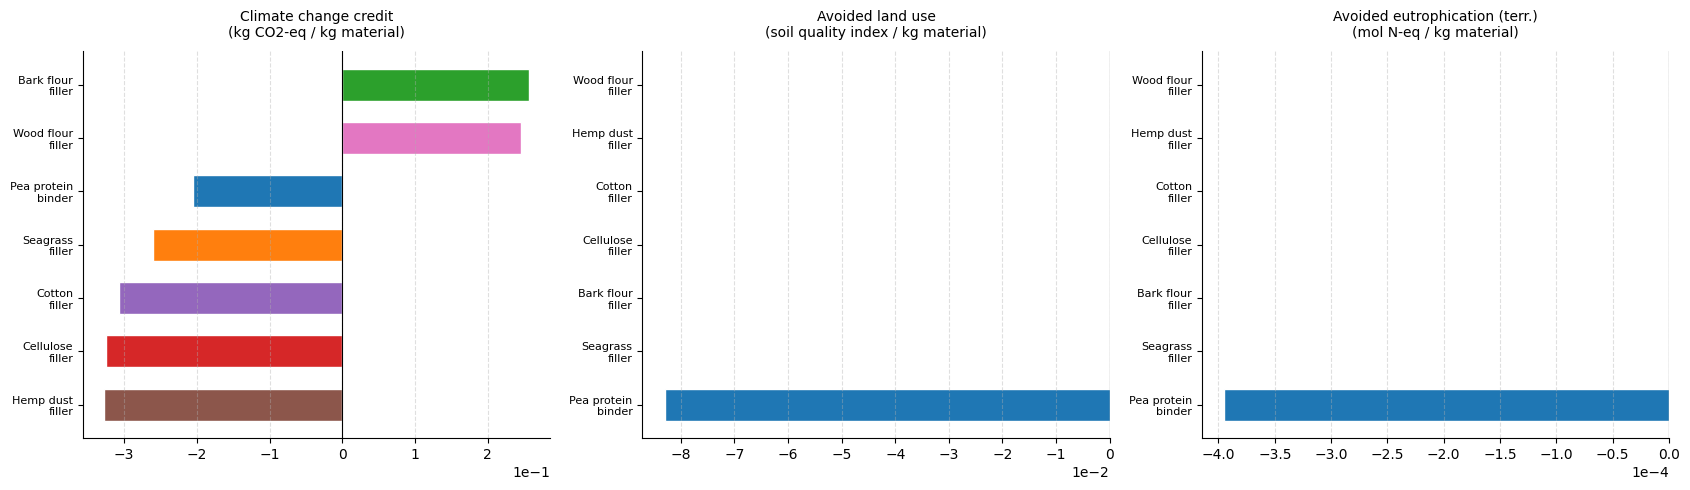

Chart saved to unit_environmental_benefits.png


In [21]:
# ── Bar charts — one row, three benefit categories ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

CHART_CONFIG = [
    ("climate change",              "Climate change credit\n(kg CO2-eq / kg material)"),
    ("land use",                    "Avoided land use\n(soil quality index / kg material)"),
    ("eutrophication: terrestrial", "Avoided eutrophication (terr.)\n(mol N-eq / kg material)"),
]

MAT_COLORS = {
    name: plt.cm.tab10.colors[i % 10]
    for i, name in enumerate(MATERIAL_ACTIVITIES.keys())
}

for ax, (col, title) in zip(axes, CHART_CONFIG):
    scores = df_benefits_full[col].sort_values(ascending=True)
    colors = [MAT_COLORS[name] for name in scores.index]

    ax.barh(range(len(scores)), scores.values, color=colors, edgecolor="white", height=0.6)
    ax.set_yticks(range(len(scores)))
    ax.set_yticklabels(
        [n.replace(" filler", "\nfiller").replace(" binder", "\nbinder") for n in scores.index],
        fontsize=8,
    )
    ax.set_title(title, fontsize=10, pad=10)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("unit_environmental_benefits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to unit_environmental_benefits.png")

In [22]:
# ── Export — long format, absolute + normalised ───────────────────────────────
df_benefits_long = (
    df_benefits_full
    .reset_index()
    .melt(id_vars="material", var_name="category", value_name="score")
)

df_benefits_long["unit"] = df_benefits_long["category"].map(EF_UNITS)
df_benefits_long["normalised_score"] = df_benefits_long.apply(
    lambda row: row["score"] / EF_NORMALISATION.get(row["category"], float("nan")),
    axis=1,
)

df_benefits_long = df_benefits_long.sort_values(["material", "category"]).reset_index(drop=True)

export_dir = "../results/for_html"
os.makedirs(export_dir, exist_ok=True)
df_benefits_long.to_csv(f"{export_dir}/perKgMaterial_benefits.csv", index=False)
print(f"Exported to {export_dir}/perKgMaterial_benefits.csv")
df_benefits_long

Exported to ../results/for_html/perKgMaterial_benefits.csv


,material,category,score,unit,normalised_score
0,Bark flour filler,acidification,0.000000,mol H+-eq,0.000000
1,Bark flour filler,climate change,0.256667,kg CO2-eq,0.000032
2,Bark flour filler,climate change: biogenic,0.000000,kg CO2-eq,0.000000
3,Bark flour filler,climate change: fossil,0.000000,kg CO2-eq,0.000000
4,Bark flour filler,climate change: land use and land use change,0.000000,kg CO2-eq,0.000000
...,...,...,...,...,...
170,Wood flour filler,material resources: metals/minerals,0.000000,kg Sb-eq,0.000000
171,Wood flour filler,ozone depletion,0.000000,kg CFC-11-eq,0.000000
172,Wood flour filler,particulate matter formation,0.000000,disease incidences,0.000000
173,Wood flour filler,photochemical oxidant formation: human health,0.000000,kg NMVOC-eq,0.000000
